In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
from torchvision.transforms.v2 import RandAugment
import torch
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
import torch.nn as nn

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import get_data_loaders
from backbone import BackBone
from multiheadmodel import MultiHeadModel
from losses.ewc import EWCCriterion
from losses.lwf import LwFCriterion
from utils import run_til_experiment, run_cil_experiment, new_model_from_backbone


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Fine Tuning Naive Task-IL

In [ ]:
criterion = nn.CrossEntropyLoss()
run_til_experiment(criterion, "Naive", device)

In [ ]:
# backbone= BackBone()
# backbone.load_state_dict(torch.load("../models/weights/backbone.pth"))
# model = MultiHeadModel(backbone)
# model.to(device)
# dataloaders = get_data_loaders(batch_size=512)

# deterministic()
# criterion = nn.CrossEntropyLoss()
# for i in range(5):
#     model.add_head(i)
#     model.to(device)
#     train_data = dataloaders[i][0]
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     epochs = 20

#     train(model, train_data, optimizer, criterion, None, epochs, task_number=i, save=False)
    
#     # Accuracy después de cada entrenamiento
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")

# # Accuracy después de terminar
# for i in range(5):
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")

# model.save(f"../models/weights/naive_Task-IL.pth")

#### Fine Tuning Naive Class-IL

In [ ]:
model = new_model_from_backbone(device)
criterion = nn.CrossEntropyLoss()
run_cil_experiment(criterion, "Naive", device, model, epochs=4)

In [ ]:
backbone= BackBone()
backbone.load_state_dict(torch.load("../models/weights/backbone.pth"))
model = MultiHeadModel(backbone)
model.to(device)
dataloaders = get_data_loaders(batch_size=512)
from utils import train, accuracy, deterministic
deterministic()
criterion = nn.CrossEntropyLoss()
for i in range(5):
    print(f"Training task {i}")
    if i == 0:
        model.add_head(i)
    else:
        model.expand_head()
    model.to(device)
    train_data = dataloaders[i][0]
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    epochs = 20

    train(model, train_data, optimizer, criterion, None, epochs, task_number=0, save=False, global_labels=True)
    
    for j in range(i + 1):
        eval_data = dataloaders[j][1]
        acc = accuracy(model, eval_data, task_number=0, global_labels=True)
        print(f"Task {j} Accuracy: {acc:.4f}")

# model.save(f"../models/weights/naive_Class-IL.pth")

### EWC TIL

In [ ]:
criterion = EWCCriterion(nn.CrossEntropyLoss(), lambda_=1)
run_til_experiment(criterion, "EWC", device)

In [ ]:
# backbone= BackBone()
# backbone.load_state_dict(torch.load("../models/weights/backbone.pth"))
# model = MultiHeadModel(backbone)
# model.to(device)
# dataloaders = get_data_loaders(batch_size=512)

# deterministic()
# criterion = EWCCriterion(nn.CrossEntropyLoss(), lambda_=1)
# for i in range(5):
#     model.add_head(i)
#     model.to(device)
#     train_data = dataloaders[i][0]
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     epochs = 20

#     train(model, train_data, optimizer, criterion, None, epochs, task_number=i, save=False)
#     criterion.consolidate(model, dataloaders[i][0], task_number=i)
    
#     # Accuracy después de cada entrenamiento
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")

# # Accuracy después de terminar
# for i in range(5):
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")
    
# model.save(f"../models/weights/EWC_Task-IL.pth")

### EWC CIL

In [ ]:
model = new_model_from_backbone(device)
criterion = EWCCriterion(nn.CrossEntropyLoss(), lambda_=50, global_labels=True, model=model)
run_cil_experiment(criterion, "EWC", device, model)

### LwF TIL

In [ ]:
model = new_model_from_backbone(device)
criterion = LwFCriterion(nn.CrossEntropyLoss(), model, lambda_=1.0, temperature=2.0)
run_til_experiment(criterion, "LwF", device, model)

In [ ]:
# backbone= BackBone()
# backbone.load_state_dict(torch.load("../models/weights/backbone.pth"))
# model = MultiHeadModel(backbone)
# model.to(device)
# dataloaders = get_data_loaders(batch_size=512)

# deterministic()
# criterion = LwFCriterion(nn.CrossEntropyLoss(), model, lambda_=1.0, temperature=2.0)
# for i in range(5):
#     model.add_head(i)
#     model.to(device)
#     train_data = dataloaders[i][0]
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     epochs = 20

#     train(model, train_data, optimizer, criterion, None, epochs, task_number=i, save=False)
#     criterion.update_teacher()
    
#     # Accuracy después de cada entrenamiento
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")

# # Accuracy después de terminar
# for i in range(5):
#     eval_data = dataloaders[i][1]
#     acc = accuracy(model, eval_data, task_number=i)
#     print(f"Task {i} Accuracy: {acc:.4f}")
    
# model.save(f"../models/weights/LwF_Task-IL.pth")

### LwF CIL

In [ ]:
model = new_model_from_backbone(device)
criterion = LwFCriterion(nn.CrossEntropyLoss(), model, lambda_=20.0, temperature=3.0)
run_cil_experiment(criterion, "LwF", device, model, epochs=4)

### Co2L Backbone training

Files already downloaded and verified


c:\Users\User\miniconda3\envs\vision\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000
Training task 0


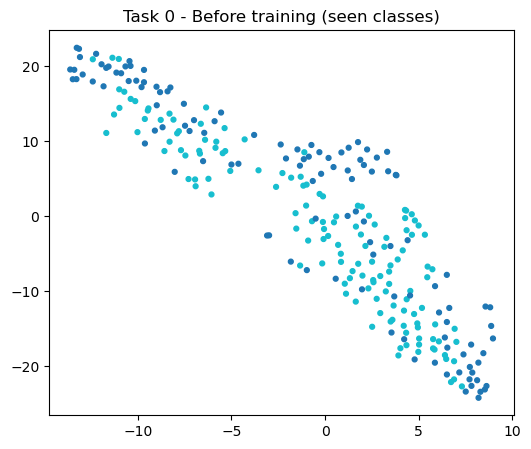

Task 0 Epoch 1/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 0 Epoch 2/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 0 Epoch 3/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 0 Epoch 4/4:   0%|          | 0/18 [00:00<?, ?it/s]

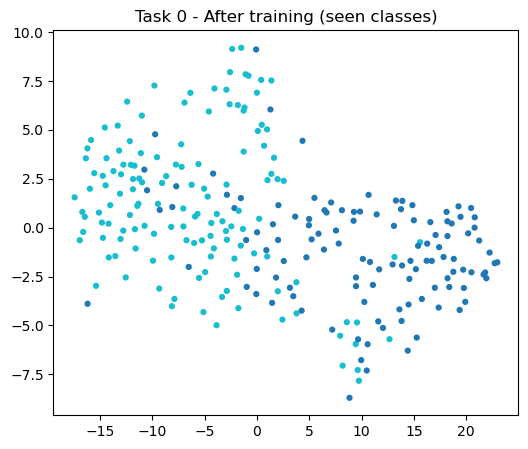

Training task 1


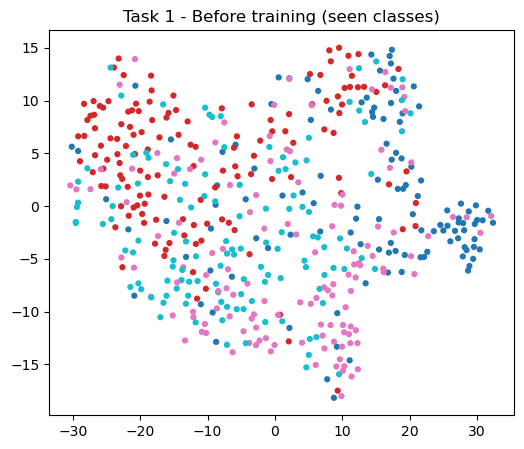

Task 1 Epoch 1/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 1 Epoch 2/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 1 Epoch 3/4:   0%|          | 0/18 [00:00<?, ?it/s]

Task 1 Epoch 4/4:   0%|          | 0/18 [00:00<?, ?it/s]

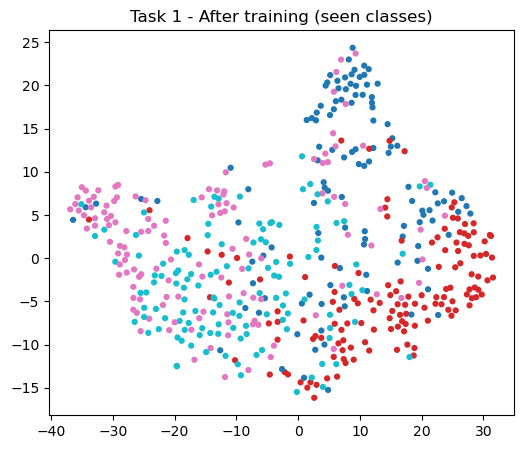

Training task 2


KeyboardInterrupt: 

In [4]:
from utils import deterministic
from replay_buffer import ReplayBuffer
from losses.supcon import SupConLoss
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import copy
import torch
import torchvision.transforms.v2 as v2

def distill_criterion(s, t, tau_s=0.2, tau_t=0.01):
    sim_s = s @ s.T
    sim_t = t @ t.T

    eye = torch.eye(sim_s.size(0), device=sim_s.device, dtype=torch.bool)
    sim_s = sim_s.masked_fill(eye, -1e9)
    sim_t = sim_t.masked_fill(eye, -1e9)

    log_p_s = sim_s / tau_s - torch.logsumexp(sim_s / tau_s, dim=1, keepdim=True)
    log_p_t = sim_t / tau_t - torch.logsumexp(sim_t / tau_t, dim=1, keepdim=True)
    p_t = log_p_t.exp().detach()

    loss = -(p_t * log_p_s).sum(dim=1).mean()
    return loss * (tau_s ** 2)

def collect_seen_samples(dataloaders, max_task_idx, max_samples_per_task=256):
    x_chunks, y_chunks = [], []
    for task_idx in range(max_task_idx + 1):
        seen = 0
        train_loader = dataloaders[task_idx][0]
        for x_batch, y_batch in train_loader:
            take = min(x_batch.size(0), max_samples_per_task - seen)
            if take <= 0:
                break
            x_chunks.append(x_batch[:take])
            y_chunks.append(y_batch[:take])
            seen += take
    x_all = torch.cat(x_chunks, dim=0)
    y_all = torch.cat(y_chunks, dim=0)
    return x_all, y_all

def plot_task_tsne(backbone_model, x_ref, y_ref, plot_title):
    backbone_model.eval()
    with torch.no_grad():
        emb = backbone_model(x_ref).detach().cpu().numpy()
    y_np = y_ref.detach().cpu().numpy()

    if emb.shape[0] < 2:
        return

    tsne = TSNE(n_components=2, random_state=42)
    emb_2d = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_np, cmap="tab10", s=12)
    plt.title(plot_title)
    plt.show()
    backbone_model.train()

deterministic(42)
title = "Co2L"
epochs = 4
batch_size = 512
buffer_size = 1000
buffer_batch_size = batch_size // 4
lambda_ = 1.0
distill_tau_s = 0.2
distill_tau_t = 0.01
tsne_samples_per_task = 256

backbone = BackBone().to(device)
optimizer = torch.optim.Adam(backbone.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
supcon_criterion = SupConLoss(tau=0.5)

view_transform = v2.Compose([
    v2.RandomResizedCrop(size=(32, 32), scale=(0.6, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=9),
])

dataloaders = get_data_loaders(batch_size=batch_size)
buffer = ReplayBuffer(buffer_size)
prev_backbone = None

for task in range(len(dataloaders)):
    print(f"Training task {task}")
    train_data = dataloaders[task][0]

    x_ref_cpu, y_ref_cpu = collect_seen_samples(
        dataloaders=dataloaders,
        max_task_idx=task,
        max_samples_per_task=tsne_samples_per_task,
    )
    x_ref = x_ref_cpu.to(device, non_blocking=True)
    y_ref = y_ref_cpu.to(device, non_blocking=True)

    plot_task_tsne(backbone, x_ref, y_ref, f"Task {task} - Before training (seen classes)")

    for epoch in range(epochs):
        if prev_backbone is not None:
            buffer_loader = buffer.get_dataloader(buffer_batch_size)
            buffer_iter = iter(buffer_loader)

        pbar = tqdm(train_data, desc=f"Task {task} Epoch {epoch+1}/{epochs}", leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            N_cur = len(x) 

            if prev_backbone is not None:
                try:
                    x_buf, y_buf = next(buffer_iter)
                except StopIteration:
                    buffer_iter = iter(buffer_loader)
                    x_buf, y_buf = next(buffer_iter)

                x_buf = x_buf.to(device, non_blocking=True)
                y_buf = y_buf.to(device, non_blocking=True)
                x_all = torch.cat([x, x_buf], dim=0)
                y_all = torch.cat([y, y_buf], dim=0)
            else:
                x_all, y_all = x, y

            N_all = len(x_all)

            x_view1 = view_transform(x_all)
            x_view2 = view_transform(x_all)
            x_two_views = torch.cat([x_view1, x_view2], dim=0)
            class_labels = y_all.repeat(2)

            # FIX 3: correct anchor mask accounting for non-contiguous layout
            # x_two_views = [view1_current | view1_buffer | view2_current | view2_buffer]
            anchor_mask = torch.zeros(2 * N_all, dtype=torch.bool, device=device)
            anchor_mask[:N_cur] = True               # view1 of current task
            anchor_mask[N_all:N_all + N_cur] = True  # view2 of current task

            projections = backbone.get_projection(x_two_views)
            loss = supcon_criterion(projections, class_labels, anchor_mask=anchor_mask)

            if prev_backbone is not None:
                with torch.no_grad():
                    prev_projections = prev_backbone.get_projection(x_two_views)
                d_loss = distill_criterion(
                    projections,
                    prev_projections,
                    tau_s=distill_tau_s,
                    tau_t=distill_tau_t,
                )
                loss = loss + lambda_ * d_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=float(loss.item()))

        scheduler.step()  

    plot_task_tsne(backbone, x_ref, y_ref, f"Task {task} - After training (seen classes)")

    prev_backbone = copy.deepcopy(backbone).eval()
    buffer.update(train_data)

backbone.save(f"../models/weights/{title}_Backbone.pth")